# Bayesian Sampling in nDspec

nDspec provides utility function that allow it to interface with most python-based inference packages. In the examples below, we will use the Affine Invariant Ensemble Sampler [emcee](https://emcee.readthedocs.io/en/stable/) and the [zeus](https://zeus-mcmc.readthedocs.io/en/latest/) Ensemble Slice Sampler, both of which are Markov Chain Monte Carlo (MCMC) algorithms. In addition, we will also show an example using the [Dynesty](https://dynesty.readthedocs.io/en/stable/), which utilizes a form of Nested Sampling. 

We note that Bayesian sampling is a very large and complex topic, and this notebook does not in any way, shape or form attempt to give exhausting information on best practices, theoretical background, etc. We strongly encouraged users to read the relevant documentation of each method, as well as the associated publications and the wider litterature. Instead, the goal of this notebook is to show users who already have some knoweledge in the topic an example of how to utilize various Bayesian sampling algorithms within nDspec.

To start with, let us set up a simple problem using a NICER time-averaged spectrum fitted with standard Xspec models We will be running an optimization algorithm to find an initial guest from the "best-fit" value, and use that point to initialize our samplers where necessary.

In [1]:
import os
import warnings

#this is necessary to disable numpy's default parallelization, which
#interferes with sampling performance.0/
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import sys
import numpy as np
import gc

#this is to remove weird font warnings
import logging
logging.disable(logging.WARNING)

sys.path.append('/home/matteo/Software/nDspec/src/')
from ndspec.Response import ResponseMatrix
import ndspec.FitTimeAvgSpectrum as fitspec
import ndspec.XspecInterface as XSModels

from lmfit import Model as LM_Model

Arf missing, please load it
Arf loaded


/home/matteo/Software/nDspec/src/ndspec/SimpleFit.py:860: UserWarning: WARNING: backscal keyword not found, check file format
  warnings.warn("WARNING: backscal keyword not found, check file format",



Initialized Xspec models:
diskbb:
  type: add
  function called: xsdskb
  parameters:
    Tin: value: 1.0, min: 0.0, max: 1000.0, unit: keV
    norm: value: 1, min: 0, max: 1e+20, unit: n/a

tbabs:
  type: mul
  function called: C_tbabs
  parameters:
    nH: value: 1.0, min: 0.0, max: 1000000.0, unit: 10^22

nthcomp:
  type: add
  function called: C_nthcomp
  parameters:
    Gamma: value: 1.7, min: 1.001, max: 10.0, unit: n/a
    kT_e: value: 100.0, min: 1.0, max: 1000.0, unit: keV
    kT_bb: value: 0.1, min: 0.001, max: 10.0, unit: keV
    inp_type: value: 0.0, min: 0.0, max: 1.0, unit: 0/1
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    norm: value: 1, min: 0, max: 1e+20, unit: n/a

 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996


tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.
/home/matteo/.local/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


-----------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 55
    # data points      = 235
    # variables        = 5
    fit statistic      = 528.020369613459
    reduced statistic  = 2.295740737449822
    Akaike info crit   = 200.24409669336225
    Bayesian info crit = 217.54202426408304
[[Parameters]]
    nH:         0.11679821 +/- 0.00784816 (6.72%) (init = 0.1), model_value = 0.1167982
    Gamma:      1.62134197 +/- 0.01872375 (1.15%) (init = 1.65), model_value = 1.621342
    kT_e:       100 (fixed)
    kT_bb:      0.27531342 +/- 0.00925560 (3.36%) (init = 0.25), model_value = 0.2753134
    norm_comp:  5.94249999 +/- 0.17148786 (2.89%) (init = 6.5), model_value = 5.9425
    Tin:        0.27531342 +/- 0.00925560 (3.36%) == '1.0*kT_bb'
    norm_disk:  5.22547140 +/- 0.07958545 (1.52%) (init = 5), model_value = 5.225471


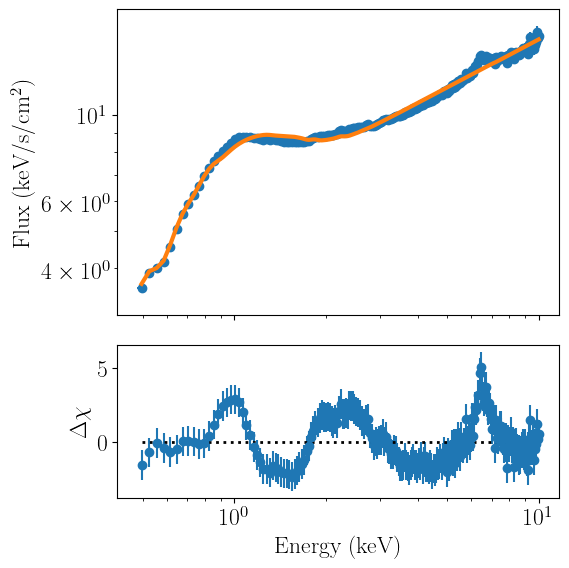

In [2]:
#this is all identical to the time-averaged fitting notebook
path = os.getcwd() + "/data/"

rmfpath = path+"1200120106_rmf.pha"
nicer_matrix = ResponseMatrix(rmfpath)
arfpath = path+"1200120106_arf.pha"
nicer_matrix.load_arf(arfpath)

spectrum_fit = fitspec.FitTimeAvgSpectrum()
spectrum_fit.set_data(nicer_matrix,path+'1200120106_rebin.pha')
spectrum_fit.ignore_energies(0,0.5)
spectrum_fit.ignore_energies(10.0,20.0)

model_library = XSModels.FortranInterface()

def tbabs(ear, params):
    pass

def diskbb(ear, params):
    pass

def nthcomp(ear, params):
    pass

def reflect(ear,params,seed):
    pass

model_library.load_models({
    "diskbb": diskbb,
    "tbabs": tbabs,
    "nthcomp": nthcomp
})

model_library.print_model_info()

def ndspec_nthcomp(ear,Gamma,kT_e,kT_bb,norm_comp):
    par_array = np.array([Gamma,kT_e,kT_bb,1,0,norm_comp])
    model = model_library.nthcomp(ear,par_array)
    return model

def ndspec_tbabs(ear,nH):
    par_array = np.array([nH])
    model = model_library.tbabs(ear,par_array)
    return model

def ndspec_diskbb(ear,Tin,norm_disk):
    norm_disk = 10**norm_disk
    par_array = np.array([Tin,norm_disk])
    model = model_library.diskbb(ear,par_array)
    return model

unfolded_model = LM_Model(ndspec_tbabs)*(LM_Model(ndspec_nthcomp)+LM_Model(ndspec_diskbb))
start_params = unfolded_model.make_params(Gamma=dict(value=1.65,min=1.1,max=4.0),
                                          kT_e=dict(value=100,min=50,max=150,vary=False),
                                          kT_bb=dict(value=0.25,min=0.10,max=1),
                                          norm_comp=dict(value=6.5,min=1e-1,max=50.),
                                          Tin=dict(value=0.25,min=0.10,max=1,expr="1.0*kT_bb"),
                                          norm_disk=dict(value=5,min=-2,max=8),
                                          nH=dict(value=0.1,min=1e-3,max=2))

spectrum_fit.set_model(unfolded_model,params=start_params)
spectrum_fit.fit_data()
spectrum_fit.plot_model(units='eeunfold')

Now that we have some guess for our parameters, we need to call several functions to initialize our samplers, be. These are contained in the ```SamplingUtils``` module, and are labelled as ```set_sampling_object_of_interest```. Let us begin by defining the data and model that will be fed to the sampler, and by retrieving the parameter values we will use to initialize our MCMC samplers.

In [3]:
import ndspec.SamplingUtils as sampling

#first, we define the data and models that will be used by the sampler
sampling.set_sampling_data(spectrum_fit)
sampling.set_sampling_model(spectrum_fit)

#we will initialize our mcmc sampler from the best-fitting parameters we just found
theta = sampling.set_sampling_parameters(spectrum_fit.model_params)
ndim = len(theta)

print(theta)

[0.11679821 1.62134197 0.27531342 5.94249999 5.2254714 ]


We now need to specify the priors for each parameter. nDspec comes with a set of classes that handle priors, but users are free to implement their own as well. If you do, in order to be compatible with the nDspec functions and classes, custom priors require a function called ```logprob```, which returns the probabily distribution p(x) for a given value x of the parameter of interest

In this case, we will simply use uninformative (flat) priors with some reasonable range for all of our model parameters. After we define each prior object, these are stored in a dictionary, with the keys named identically to the parameters in the ```FitTimeAveragedSpectrum``` object we are working with, and stored by calling the ```set_sampling_priors``` function.

Finally, we can sanity check that our log-likelihood (in this case, a Gaussian likelihood) actually makes sense by printing the value obtaing from calling ```mcmc_gaussian_likelihood```. There are two important things to know about the likelihood function used:
1. The optimizers in LMFit use the positive log likelihood, while (most) Bayesian sampling packages use -0.5*log likelihood
2. ```mcmc_gaussian_likelihood``` returns the numerator on Bayes' theorem - the likelihood multiplied by the prior probability
Therefore, if your prior is flat, you should find that, given identical parameters, ```mcmc_gaussian_likelihood``` returns exactly minus one-half what a ```Fitter``` object reports. This is purely a convention required to get all the libraries to function together. If your priors are not flat, then this value will be further modified by the prior probability.

In [4]:
#now let us define the priors we will use. In this case, we will just use uniform priors for all the parameters
nH_prior = sampling.priorUniform(0.05,0.5)
Gamma_prior = sampling.priorUniform(1.3,2.0)
kT_bb_prior = sampling.priorUniform(0.1,0.7)
norm_comp_prior = sampling.priorUniform(1,20)
norm_disk_prior = sampling.priorUniform(4,6)

#now we build a dictionary of prior objects, each assigned to one of our parameters
my_priors = {
    "nH": nH_prior,
    "Gamma": Gamma_prior,
    "kT_bb": kT_bb_prior,
    "norm_comp": norm_comp_prior,
    "norm_disk": norm_disk_prior
}

#and finally we set the priors the sampler will use
sampling.set_sampling_priors(spectrum_fit,my_priors)

#finally, we can sanity check our initial guess by calculating the likelihood. In the case of emcee and other MCMC algorithms,
#the function that gets called needs to include the product of likelihood*priors.
likelihood = sampling.mcmc_gaussian_likelihood(theta)
print("mcmc likelihood",likelihood)

mcmc likelihood -264.0101848067295


Once the priors are defined, we can follow the usual recipe for ```emcee``` (or most other sampling codes) to define and run our Bayesian sampler

In [5]:
import emcee

nwalkers = 10*ndim
steps = int(1000)

#pos is the initial positions of the walkers - we will set it to be within 1% of the best fitting values
pos = theta*(1+ 1e-2 * np.random.randn(nwalkers, len(theta)))

basic_sampler = emcee.EnsembleSampler(nwalkers, ndim, sampling.mcmc_gaussian_likelihood)

In [6]:
basic_sampler.run_mcmc(pos, steps, progress=True);

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:17<00:00,  3.15it/s]


And because we are using ```emceee```, we also have access to all the moves provided in that library. For example, instead of the default stretch move, we can try a Differential Evolution move. Again, for more in-depth information, users are encouraged to read the ```emcee``` documentation and its associated publications:

In [7]:
de_sampler = emcee.EnsembleSampler(nwalkers, ndim, sampling.mcmc_gaussian_likelihood,
                                   moves=[emcee.moves.DEMove()])
de_sampler.run_mcmc(pos, steps, progress=True);

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:01<00:00,  3.32it/s]


We can also utilize any other library that performs ensemble sampling - ultimately, no matter the algorithm, all we need is to follow the setup steps above, which then allows to provide a likelihood function for MCMC to sample. For example, if we wanted to use ```zeus```:

In [8]:
import zeus 

#ensemble slice sampling does not need as many walkers
nwalkers = 4*ndim
pos = theta*(1+ 1e-2 * np.random.randn(nwalkers, len(theta)))

slice_sampler = zeus.EnsembleSampler(nwalkers, ndim, sampling.mcmc_gaussian_likelihood) 
slice_sampler.run_mcmc(pos, steps) 

Sampling progress : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [11:37<00:00,  1.43it/s]


Now that we have run the samplers, we can compute the auto-correlation times for each. This is an extremely important metric, because it tells us whether we have actually run the samplers for a sufficiently long time. 

A good rule of thumb is that the sampler should run for on the order of 50 or so auto-correlation times; shorter chains are extremely likely to return biased or incorrect posteriors, as they won't have drawn a large enough sample size to reconstruct the posterior distribution sufficiently well. 

In this case, given the simplicity of the problem we should be (mostly) convinced that our sampling was effective and our posteriors are reconstructed effectively.

In [9]:
tau_basic = basic_sampler.get_autocorr_time(tol=1)
print(tau_basic)

tau_de = de_sampler.get_autocorr_time(tol=1)
print(tau_de)

slice_samples = slice_sampler.get_chain(discard=0,thin=1)
tau_slice = zeus.AutoCorrTime(slice_samples,method='dfm')
print(tau_slice)

[33.16226973 37.13353641 33.92793976 36.98437884 33.27510035]
[17.07928525 17.77855182 17.2031722  17.27540753 17.27894343]
[13.36094658 10.16498897 13.5566717  12.67631576 13.59962797]


Having checked for convergence, we can discard the initial burn-in phase of the chain (the time it takes for the algorithms "forgets" their starting position), thin the chains by ignoring one every N samples, and then plotting the posteriors reconstructed by all 3 algorithms. In this case, we are happy to see that all three have converged to identical distributions, meaning we can be confident our estimates for the posteriors.

In addition, we note from the corner plots that many of the parameters are linearly correlated with each other; despite this, the auto-correlation lengths for all three samplers are very short, and the samplers are generally very efficient and well behaved. This should not be at all surprising: all the samplers used here (and really, most modern samplers) are _affine invariant_, meaning that their performance is entirely immune to linear correlations between parameters. This also means that, when possible, we should attempt to re-formulate our problem to make correlations be strictly linear - for example, in case of ```diskbb```, by working with the log10 of the normalisation, rather than the normalisation itself.

50

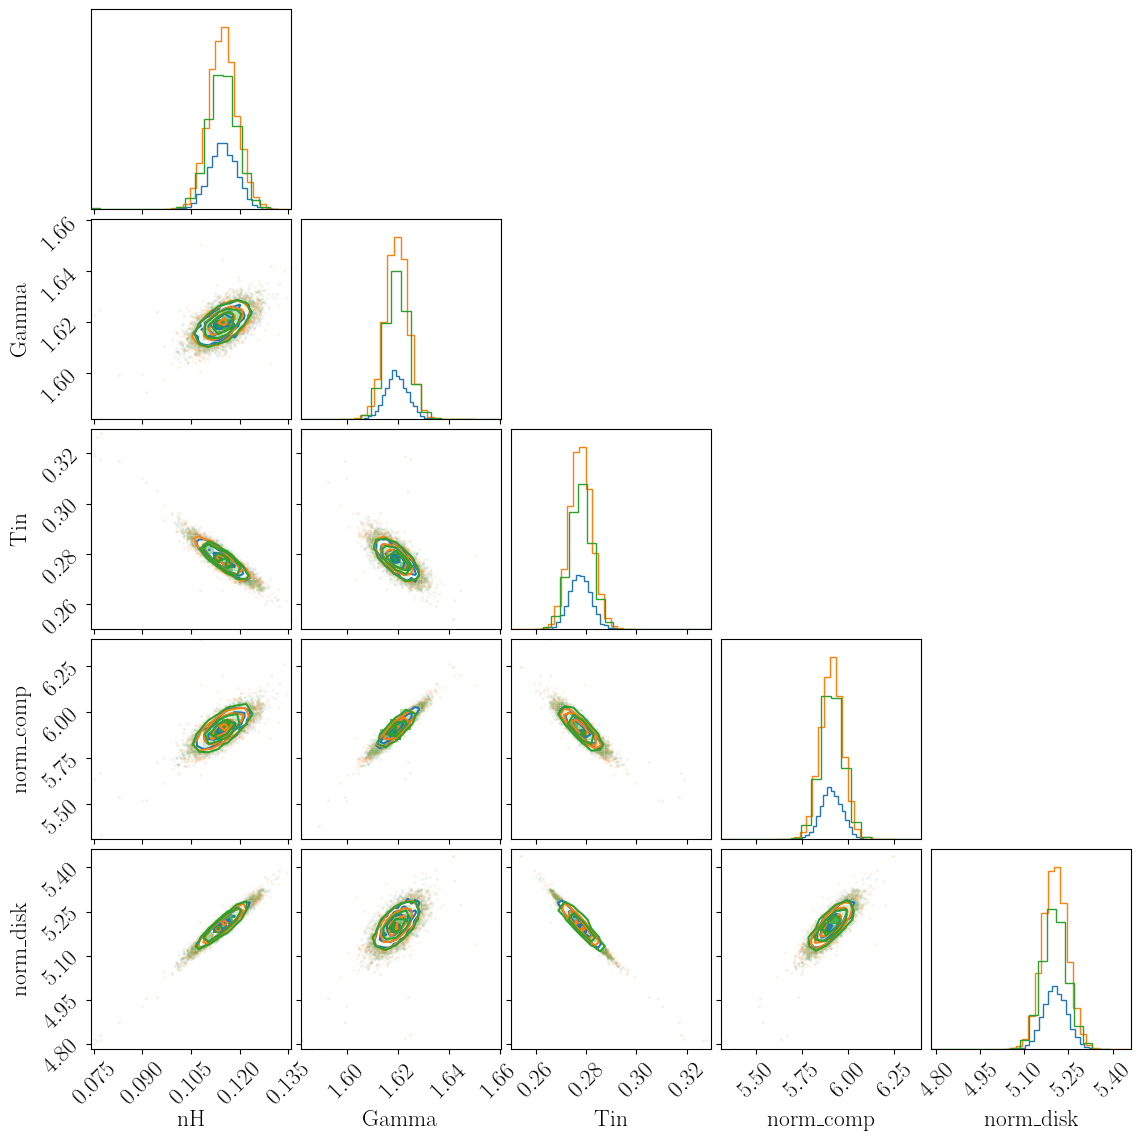

In [10]:
import corner
import gc

thin_basic = np.mean(tau_basic)
thin_de = np.mean(tau_de)
thin_slice = np.mean(tau_slice)

basic_samples = basic_sampler.get_chain(discard=int(2*thin_basic), thin=int(0.5*thin_basic), flat=True)
de_samples = de_sampler.get_chain(discard=int(2*thin_de), thin=int(0.5*thin_de), flat=True)
slice_samples = slice_sampler.get_chain(discard=int(2*thin_slice), thin=int(0.5*thin_slice), flat=True)

labels=["nH","Gamma","Tin","norm_comp","norm_disk"]

#note that the first sampler has a longer autocorrelation lenght, meaning it contains fewer samples,
#meaning the normalization of the distribution is lower even if the intervals and shape are identical.
fig = corner.corner(basic_samples, labels=labels,color="C0")
fig = corner.corner(de_samples, labels=labels,color="C1",fig=fig)
fig = corner.corner(slice_samples, labels=labels,color="C2",fig=fig)

gc.collect()

Now let us try nested sampling. Because of how the algorithm is built, we actually need to provide two functions: one which converts the interval 0-1 (which nested sampling draws from) into the prior space of each parameter, and one which computes the likelihood _without_ modifying it by the prior probability. These are both provided within nDspec. 

In particular, the prior classes contain a method called ```transform_prior```, which returns the percent point function (the inverse of the cumulative distribution function). The function ```nested_sampling_prior``` calls this method for all the priors defined by ```set_sampling_priors```. Users that want to define their own custom priors should define a method that does the same.

The likelihood function, unmodified by the prior, is instead returned by ```sampling_gaussian_likelihood```. Users can also use other functions provided by nDspec (e.g. ```sampling_cash_likelihood``` for Poisson data), or their own custom function if they so choose.

Once we have these, we can set up a nested sampling run as we would any other algorithm.

In [11]:
import dynesty

nestedsampler = dynesty.DynamicNestedSampler(sampling.sampling_gaussian_likelihood, sampling.nested_sampling_priors, ndim ,nlive=100,
                                             sample='rwalk')
nestedsampler.run_nested(dlogz_init=3)

13904it [38:56,  5.95it/s, batch: 21 | bound: 6 | nc: 1 | ncall: 336908 | eff(%):  4.098 | loglstar: -276.239 < -263.993 < -265.252 | logz: -289.384 +/-  0.158 | stop:  0.984]          


Having run the sampler to convergence, we can use the built-in plotting utilities from ```Dynesty``` to plot our posteriors, which are unsurprisingly identical to those we found already with MCMC.

50

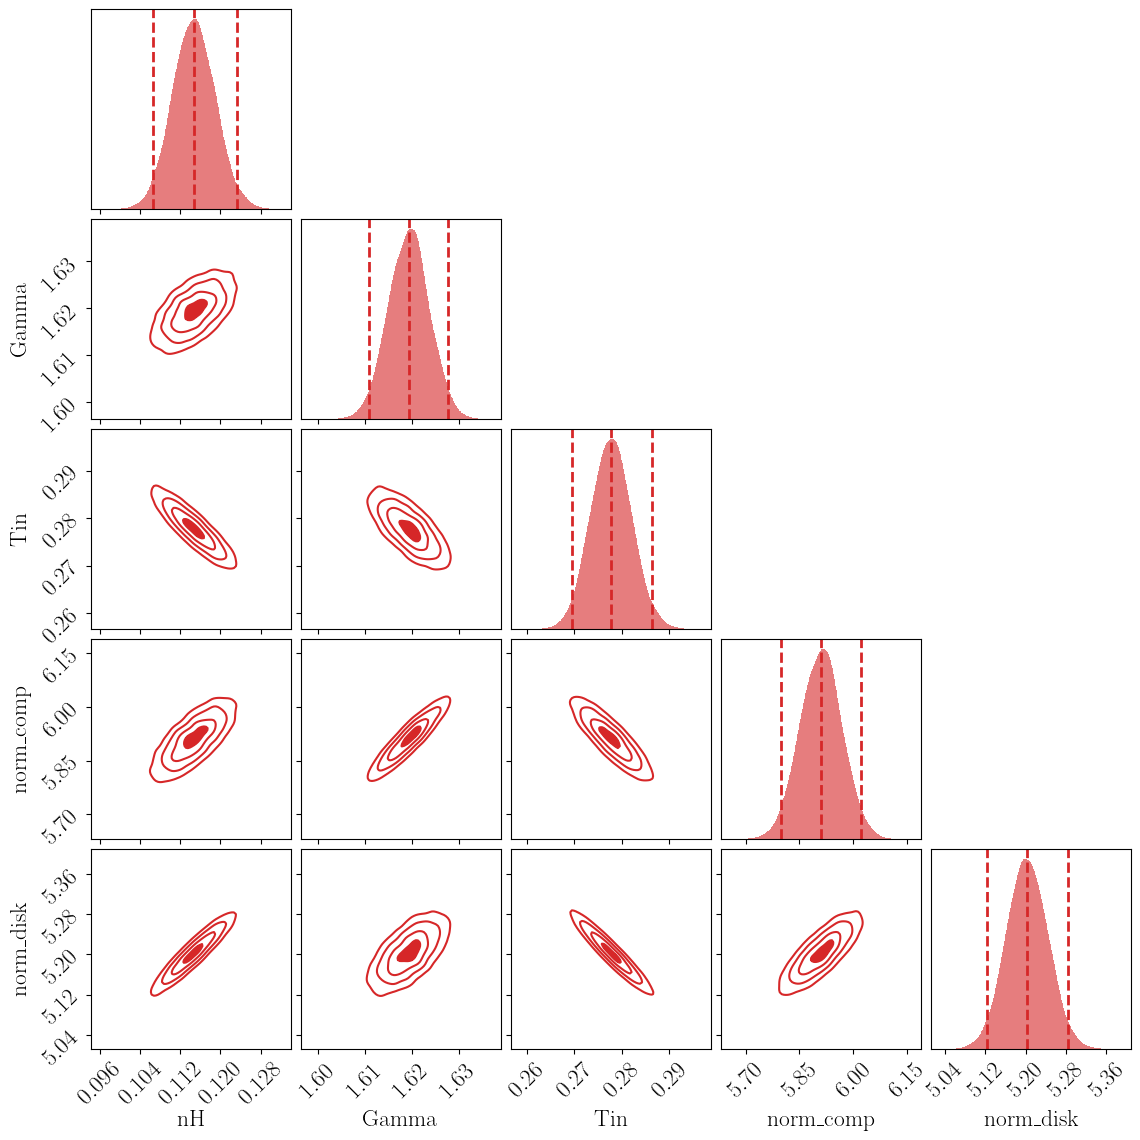

In [12]:
from dynesty import plotting as dyplot

dynesty_results = nestedsampler.results

cfig, caxes = dyplot.cornerplot(dynesty_results,labels=labels,color="C3")

gc.collect()